# INFO 264, Group Exam 2025
### Kandidate numbers: 0000, 0000, 0000, 000
---
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
### <u>Noe av det som står at vi må ha med!!!</u>
#### Important and relevant properties about the data
#### Your preprocessing steps. For example: your process of feature selection and it's results, your choices when it comes to dimension reduction (why/why not/which method/why that method) etc.
#### Based on what you have learnt from the data, why do you think that your models are best-suited for the task
#### Why the particular parameters of a model that you use, work best
#### How you control over- and underfitting
#### Your choice of evaluaon methods. Which metrics did you choose and why? Addionally, you need to give an explanation based on your intuition about why given methods perform better or worse on the given task. 
#### Finally, as a concluding comment in the Jupyter notebook, you need to write a summary of your results, and discuss consequences of such results. 
#### Please provide the list of libraries you use in the form of a `requirements.txt` in the format used by pip. 

===============================-================================

# Task 1 Sentiment Analysis
### a) Exploratory data analysis and prepocessing
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Gain a sufficient understanding of the data for
model development and perform data cleaning and feature engineering steps if you find it
necessary. You may make any changes to your dataset; however, you must attempt to give a
reason as to why you find a given transformation necessary. 

===============================-================================

## The data

---
#### Non relevant data
* When looking at the data we found many columns unnecessary for our sentiment analysis. Here we list them down with a small explanation why.
* Hotel_Address - Since we are not using the locations to map out which locations have more negative or positive. We found this not relevant.
* Additional_Number_of_Scoring - Kinda uknown what the scoring does. We found this not relevant.
* Review_Date - Knowing the data of which the review was written is not relevant for our analysis.
* Average_Score - The average score the reviewer gives is not relevant since it doesn't give any information about their review.
* Hotel_Name - Like with Hotel_Address it is not relevant analysis if we don't want to see if the hotel has more negative or positive reviews.
* Reviewer_Nationality - The nationality does not give any information if the review is negative or not, we found this not relevant.
* Review_Total_Negative_Word_Counts - Having a word count does not give enough good information about the review, we found this not relevant.
* Total_Number_of_Reviews - Does not give information about the specific review, we found this not relevant.
* Review_Total_Positive_Word_Counts - Same explanation as Review_Total_Negative_Word_Counts, does not give a gurantee that it is positive or negative, we found this not relevant.
* Total_Number_of_Reviews_Reviewer_Has_Given - The amount of reviews the author has created does not give information aobut what the review is about, we found this not relevant.
* Tags - Could be relevant but in our case we found the data not relevant to predict if the review was positive, neutral or negative.
* Days_since_review - Not relevant as it doesn't give information if the review was negative or not.
* lat - Knowing the latitude does not give valuable information about the review.
* lng - Same explanation as lat

#### Relavant data

* Negative_Review - Super relevant for our task, this is one of the reviews we want to analyse to make our prediction.
* Positive_Review - Super relevant as we want analyse the authors review to predict if they were negative, neutral or positive.
* Reviewer_Score - Super relevant as this will be served as our ``target_labels``.
 

## Preprocessing steps
---
#### <u>Har bare sett på det vi foreløpig gjør, også skrevet noen ord om det!!!</u>
* Remove unnecessary columns from the dataset
    * Takes in the whole dataset and creates a new dataset with the columns that we need.
* Removing special characters
    * Special characters don't really add any semantic meaning to the text, and they can also increase the vocabulary, because words like "room!" and "room?" will be treated as two different words. We should mention that some special characters like emojis, can carry sentiment meaning. Another example is special characters used in urls or email addresses. This can lead to some unreliable results, but these types of characters are not pressent in our dataset to the point where it would actually affect the results
* Removing single characters
    * Single characters can be typos, don't carry sentiment meaning, and will increase the vocabulary.
* Convert multiple spaces to one space
    * Having consistency with spacing, is important for tokenization
* Removing prefixes
    * Much like special characters, prefixes can increase the vocabulary, but it's important to remember that changing the prefix can also change the meaning of words.
* Convert to lowercase
    * Just as some of the other preprocessing steps, converting to lowercase letters will reduce the vocabulary.
* Lemmatizing words
    * Lemmatizing reduces words to their base, dictionary form. This ensures that words with the similar meaning is treated the same, and it also help the model to better understand the underlying meaning of the words. Lemming will always produce valid words, and consider context and meaning. This is opposed to Stemming, that might produce words that have no meaning, and it does not look at context. It is important to note that lemmatization comes at a cost compared to Stemming, but the increased cost is generally worth it compared to Stemming.
* Removing stopwords
    * Removing words that has no significant sentiment meaning. This also helps with reducing the vocabulary size. Important to note that the standard stopwords package contains words with sentiment meaning. This is something we were wary of, and so we could have added some of those words back.


### Preprocessing setp 1
The function, `csvConverzzion`, takes in the dataset and reads the three columns `Negative_Review`, `Positive_Review` and `Reviewer_Score`. It converts the data to a `NumPy` array to iterate over the rows. The new dataset contains only the necessary columns for our models, and is reordered for consistency.

In [3]:
import pandas as pd
def csvConverzzion(_Path, _sPathNew, _useCols = ["Negative_Review", "Positive_Review", "Reviewer_Score"], _sEncoding = "utf-8"):
    _dataset = pd.read_csv(_Path, usecols = _useCols)
    _mergedReviews = []
    for i in _dataset.to_numpy():
        _mergedReviews.append([ i[2], i[0], i[1] ])
    pd.DataFrame(_mergedReviews, columns = ["Reviewer_Score", "Negative_Review", "Positive_Review"]).to_csv(_sPathNew, encoding = _sEncoding)

csvConverzzion('./data/Hotel_Reviews.csv', "./data/Hotel_Reviews_Reduced.csv")

### Preprocessing step 2
All of our models goes through this step, but the functions used is dependent on the model.

1. <u> All models:</u>
    * Every single model we use start på using `combine_reviews` to combine the reviews from the dataset.
    * While `combine_reviews` is combining the reviews, it also calls `clean_sentences` on both columns, on each row, to remove special characters, single characters, replaces multiple spaces with one space, removes prefixes, converts to lowercase, lemmatizes the words and removes stopwords. All this is done to get more consistent text, as well as remove unnecessary words that only serve to increase the vocabulary.
    * For evalutaing our models we decided that using ``accuracy`` would be the best metric to train our models. Since it's creating a recognizable pattern for negative, neurtal and positive.

2. <u>The LSTM model uses the following:</u>
    * The `target_score_to_n` function is used to convert the score associated with each review, into one-hot encoded labels `[0, 1, 0]`. This is done to represent the target classes `negative`, `positive` and `neutral`. By converting the classes to numerical arrays, we make them suitable for training. One-hot encoding labels are also needed when using loss functions like `categorical_crossentropy`.
    * This is all done to standardize the text and reduce noice, which helps the LSTM model focus on meaningful patterns

3. <u>The KNN model uses the following:</u>
    * Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt.
    * Ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in. 
    * Voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

4. <u>The NLP model uses the following:</u>
    * For our target data we use `target_score_to_expression` which takes the `reviewer_score` from the dataset to represent them with `negative`, `positive` and `neutral`. Here we don't use one-hot encoded labels since it's more readable than, `[0, 1, 0]`. The target value isn't really that relevant when training our model so that's why we chose a more readable approach.
    * In addition we use a `CountVectorizer` to turn our `review_strings` to a fitted `bag_of_words` for our model which you will see below.

5. <u>The CNN model uses the following:</u>
    * Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt.
    * Ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in. 
    * Voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.

In [121]:
# Importing the default libraries that are needed for the second step in the preprocessing process.
import nltk
# nltk.download('stopwords') # Trenger bare å kjøre første gang
# nltk.download('wordnet') # Trenger bare å kjære første gang
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
import re
from nltk.stem import WordNetLemmatizer
from gensim.utils import simple_preprocess

stemmer = WordNetLemmatizer()

In [137]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Fjernet Lowercase converting herfra fordi gensim simple_preprocess gjør det by default.
# Fjernet model spesifikke funksjoner ettersom vi kaller de enkle funksjonene når vi trenger dem.
# Fjernet target_score_to_n
# ===================================================================

# The clean_sentences function has been heavily inspired by "https://stackabuse.com/text-classification-with-python-and-scikit-learn/" text processing.
 
# An indenpendent function that cleans the sentences up.
# Returns a list of the cleansed sentences, and the data variable which was used.
def clean_sentences(data):
    all_text = []
    for sen in range(0, len(data)):
        # Remove all the special characters
        text = re.sub(r'\W', ' ', str(data.iloc[sen]))
        # Remove all numbers
        text = re.sub(r'\d', ' ', text)
        # remove all single characters
        text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
        # Remove single characters from the start
        text = re.sub(r'\^[a-zA-Z]\s+', ' ', text) 
        # Substituting multiple spaces with single space
        text = re.sub(r'\s+', ' ', text, flags=re.I)
        # Removing prefixed 'b'
        text = re.sub(r'^b\s+', '', text)
        # Lemmatization
        text = text.split()

        # Converting to Lowercase
        for c in range(len(text)):
            text[c] = text[c].lower()

        text = [stemmer.lemmatize(word) for word in text if word not in (stop_words)]
        text = ' '.join(text)

        all_text.append(text)
    return all_text

def combine_reviews(data):
    X_1, X_2 = clean_sentences(data["Negative_Review"]), clean_sentences(data["Positive_Review"])
    X = []
    for n in range(len(X_1)):
        if X_1[n] == 'negative' or X_1[n] is None:
            X.append(X_2[n])
        elif X_2[n] == 'positive' or X_1[n] is None:
            X.append(X_1[n])
        else:
            X.append(X_1[n] + " " + X_2[n])
    return pd.array(X)

# Small change to threshhold to balance the data
def target_score_to_expression(data):
    y_n = data["Reviewer_Score"].values
    y = []
    for value in y_n:
        if value < 6:
            y.append("negative")
        elif value < 8:
            y.append("neutral")
        else:
            y.append("positive")
        
    return pd.array(y, dtype='object')

### b) Models
===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============

Build four (4) machine learning models for labelling sentiment behind hotel reviews.
One of the models needs to be a neural network (e.g. LSTM). You are welcome to train
models that are not covered in the course. Evaluate the performance of the built models
using the appropriate evaluation metrics 

===============================-================================

##### When building our LSTM model and how to preprocess we used this repository as a guideline to create a suitable model for our task: "https://github.com/sergiovirahonda/TweetsSentimentAnalysis/blob/main/TweetsSentimentPredictions.ipynb"

In [123]:
train = pd.read_csv('./data/Hotel_Reviews_Reduced.csv')

#### Model Imports
All the imports needed for our models

In [ ]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Fjernet duplikater og ubrukte funksjoner

# ===================================================================

# Importing the necessary libraries for the LSTM model.
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import tensorflow as tf
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras import layers, datasets, models, callbacks
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
warnings.filterwarnings('ignore')

Combine the negative and positive reivew column on each row. During the combining process, the words are also cleaned by removing special characters, single characters, multiple spaces, prefixes and at the end it also lemmatizes the words. Since we are going to process y some more and the NLP model will not need it, we save y_nlp as it's own variable.

In [138]:
X = combine_reviews(train)
y = target_score_to_expression(train)
y_nlp = target_score_to_expression(train)

One-hot encode the labels

In [11]:
labels = np.array(y)
y = []
for i in range(len(labels)):
    if labels[i] == 'neutral':
        y.append(0)
    if labels[i] == 'negative':
        y.append(1)
    if labels[i] == 'positive':
        y.append(2)
y = np.array(y)
labels = tf.keras.utils.to_categorical(y, num_classes=3)

In [ ]:
# ===============[ FJERN DETTE FØR SISTE INNLEVERING ]===============
# Med fullført preprocessing så har vi følgende mengde ord:
# 10331478 ord
# 73439 unike ord
# 18941 ord forekommer 5 ganger eller mer
# 95% av reviews er 55 ord eller færre 
# ===================================================================

#### LSTM Model

Since we had to use a neural network we chose the recomended one which was LSTM. We have tried and failed many times with this model, but with a little guideline we have created a very optimal solution to the task. As we change weights based on accuracy it will most likely be the best model. In addition it is quite more powerful than some of the other models we have used.

For faster training, we have opted to use tensorflow with a GPU.

In [ ]:
max_words = 5000
max_len = 55

# Tokenize and pad the data.
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
reviews = pad_sequences(sequences, maxlen = max_len)

X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(reviews, labels, random_state = 0)

#### Training the LSTM model

We add an ``Embedding`` with the ``max_words`` since this is how many features we have in our tokeinzer. Next we add a ``Masking`` with the ``mask_value ``set to 0 to skip any timestep equal to the ``mask_value``. Next we add a layer with 20 units of ``LSTM`` with a ``dropout`` of 0.3 to prevent overfitting. We use the ``activation="relu"`` since this activation is efficient and works nicely with sentiment analysis. In our last layer we create an output layer with 3 ``Dense`` units with an ``activation="softmax"`` since we most likely wont a prediction percentage than a float value between for example -200 and 200. In our compiler we use an ``optimizer="rmsprop"`` which works quite nicely with our task, in addition we look at out ``loss`` based on the `categorical_crossentropy` which is the best loss method for our task with 3 outputs with ``one-hot encoders``. As we said earlier we use the metric `accuracy` to train our model to be the best. In addition we add a `ModelCheckpoint` to save the best model we got under our training.

In [ ]:
with tf.device('/GPU:0'):
    model1 = Sequential()
    model1.add(layers.Embedding(max_words, 20))
    model1.add(layers.Masking(mask_value=0))
    model1.add(layers.LSTM(20,dropout=0.3, activation='relu'))
    model1.add(layers.Dense(3,activation='softmax'))
    model1.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics=['accuracy'])

    # Implementing model checkpoins to save the best metric and do not lose it on training.
    checkpoint1 = ModelCheckpoint("best_model1.keras", monitor='val_accuracy', verbose=1,save_best_only=True, mode='auto',save_weights_only=False)
    history = model1.fit(X_train_LSTM, y_train_LSTM, epochs=10, batch_size=512,validation_data=(X_test_LSTM, y_test_LSTM),callbacks=[checkpoint1])

Epoch 1/10
755/756 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6797 - loss: 0.7406
Epoch 1: val_accuracy improved from -inf to 0.73188, saving model to best_model1.keras
756/756 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step - accuracy: 0.6798 - loss: 0.7404 - val_accuracy: 0.7319 - val_loss: 0.5954
Epoch 2/10
755/756 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7330 - loss: 0.5946
Epoch 2: val_accuracy improved from 0.73188 to 0.73923, saving model to best_model1.keras
756/756 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.7330 - loss: 0.5946 - val_accuracy: 0.7392 - val_loss: 0.5764
Epoch 3/10
754/756 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7418 - loss: 0.5762
Epoch 3: val_accuracy improved from 0.73923 to 0.74342, saving model to best_model1.keras
756/756 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.7418 - loss: 0.5762 - val_accuracy: 0.7434 - val_loss: 0.5783
Epoch 4/10
755/756 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7457 - loss: 0.5660
Epoch 4: val_accuracy improv

In [58]:
# Load the best model obtained during training
best_model_LSTM = keras.models.load_model("best_model1.keras")

In [ ]:
# Evaluate the model and print out the accuracy.
test_loss_LSTM, test_acc_LSTM = best_model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
print('Model accuracy: ',test_acc_LSTM)

4030/4030 - 13s - 3ms/step - accuracy: 0.7495 - loss: 0.5568
Model accuracy:  0.7495249509811401


4030/4030 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step


<Axes: >

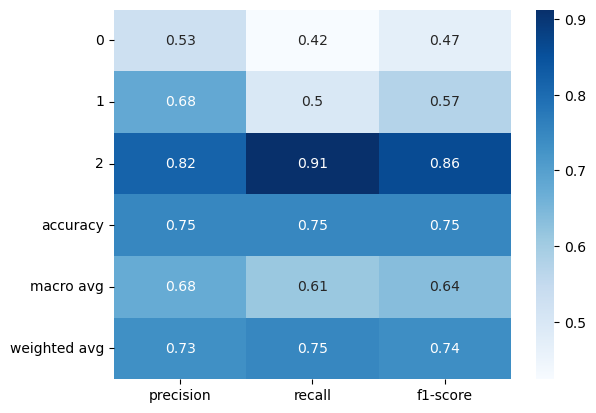

In [ ]:
# Create a classification report and use seaborn to show it.
predictions = best_model_LSTM.predict(X_test_LSTM)
clf_report_LSTM = classification_report(np.argmax(y_test_LSTM, axis=1), np.argmax(predictions, axis=1), output_dict=True)


sns.heatmap(pd.DataFrame(clf_report_LSTM).iloc[:-1, :].T, annot=True, cmap="Blues")

<Axes: >

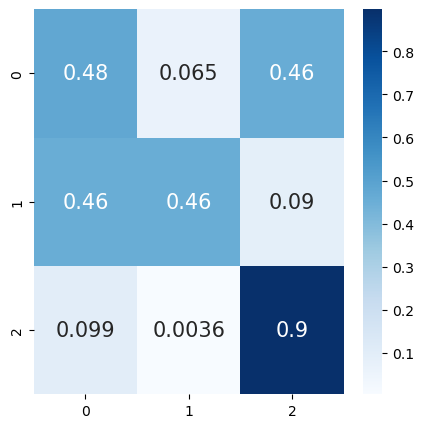

In [ ]:
# Create a confusion matrix.
matrix = confusion_matrix(y_test_LSTM.argmax(axis=1), np.around(predictions, decimals=0).argmax(axis=1))

conf_matrix = pd.DataFrame(matrix, index = ['Neutral','Negative','Positive'],columns = ['Neutral','Negative','Positive'])
conf_matrix = np.array(conf_matrix).astype('float') / np.array(conf_matrix).sum(axis=1)[:, np.newaxis]
plt.figure(figsize = (5,5))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 15}, cmap="Blues")

#### KNN Model
Convert the one-hot encoded labels to a 1D array

In [15]:
labels_convert_KNN = np.argmax(labels, axis=1)

Vectorizing the reviews

In [ ]:
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range = (1, 1), min_df = 5)
vectorize_reviews = vectorizer.fit_transform(X) 

KeyboardInterrupt: 

Split the data into training and testing sets. Testing on 20% of the data with a random state at 42 because that's the answer to life, the universe, and everything

In [ ]:
X_train_KNN, X_test_KNN, y_train_KNN, y_test_KNN = train_test_split(vectorize_reviews, labels_convert_KNN, test_size = 0.2, random_state = 42)

TypeError: Singleton array array(<gensim.models.word2vec.Word2Vec object at 0x00000235C5359E20>,
      dtype=object) cannot be considered a valid collection.

In [ ]:
k = 3
knn = KNeighborsClassifier(n_neighbors = k)
knn.fit(X_train_KNN, y_train_KNN)
y_pred_train = knn.predict(X_train_KNN)
y_pred_test = knn.predict(X_test_KNN)

MemoryError: Unable to allocate 1023. MiB for an array with shape (325, 412590) and data type float64

In [17]:
matrix = sklearn.metrics.confusion_matrix(y_pred_test, y_test_KNN)

train_accuracy = accuracy_score(y_train_KNN, y_pred_train)
test_accuracy = accuracy_score(y_test_KNN, y_pred_test)
overfitting = train_accuracy - test_accuracy

NameError: name 'y_pred_test' is not defined

In [ ]:
print("k = 3")
print(matrix)
print(f'train_accuracy: {train_accuracy}')
print(f'test_accuract: {test_accuracy}')
print(f'overfitting: {overfitting}')
print("--------------------------------------------------")

k = 3
[[ 6930   424  5856]
 [   81    79    27]
 [26989  1662 61100]]
train_accuracy: 0.7276521486221188
test_accuract: 0.6603036413696824
overfitting: 0.06734850725243635
--------------------------------------------------


#### NLP Model

We use this model since Natural Language Processing models are widely used when tackling sentiments analysis.

As per "Zubair Ashfaque" from "https://medium.com/@zubairashfaque/sentiment-analysis-with-naive-bayes-algorithm-a31021764fb4":  

__Sentiment Analysis with the Naive Bayes algorithm is a powerful approach, using probability and linguistic analysis to categorize text sentiments as positive, negative, or neutral. By preprocessing text, calculating log priors, and deriving log-likelihoods, this method quantifies sentiment, guiding accurate classification.__

<br>

After doing some testing with both `MultinomialNB` and `BernoulliNB` we found that `MultinomialNB` had the best accuracy with our data which is our score metric to our models. In addition we also experimented with `CountVectorizer` and `TfdifVectorizer` and found that `CountVectorizer` was a better fit with the data to get the most accurate model. Even though `TfdifVectorizer` was better overall at finding positive reviews.

In [ ]:
# Since the dataset is so huge, we use the 5000 of the most common words, and we want to use the words that contains in at least 5 reviews. In addition we use words
# that are in a maximum of 60% of our reviews to remove non meaningful reviews.
cv = CountVectorizer(max_features=5000, min_df=5, max_df=0.6)
X_nlp = cv.fit_transform(X)

X_train_NLP, X_test_NLP, y_train_NLP, y_test_NLP = train_test_split(X_nlp, y_nlp, test_size=0.2, random_state=42)

MultinomialNB:
{'negative': {'precision': 0.49183673469387756, 'recall': 0.5184249906472129, 'f1-score': 0.5047809853383116, 'support': 10692.0}, 'neutral': {'precision': 0.46084821806484383, 'recall': 0.4274329682408825, 'f1-score': 0.4435120878225626, 'support': 25473.0}, 'positive': {'precision': 0.8182324327492234, 'recall': 0.8337339324903333, 'f1-score': 0.825910452175842, 'support': 66983.0}, 'accuracy': 0.7007115988676464, 'macro avg': {'precision': 0.5903057951693149, 'recall': 0.5931972971261429, 'f1-score': 0.5914011751122388, 'support': 103148.0}, 'weighted avg': {'precision': 0.696141157065129, 'recall': 0.7007115988676464, 'f1-score': 0.6981876674917186, 'support': 103148.0}}


<Axes: >

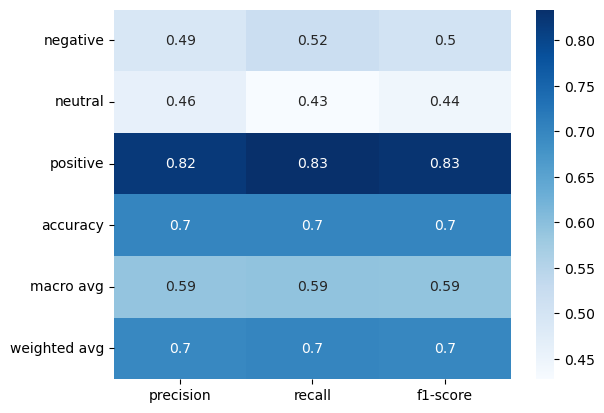

In [ ]:
# Train the model and create a classification report.
print("MultinomialNB:")
nlp_model = MultinomialNB()
nlp_model.fit(X_train_NLP, y_train_NLP)
y_pred_nlp = nlp_model.predict(X_test_NLP)
clf_report_NLP = classification_report(y_test_NLP, y_pred_nlp, output_dict=True)
print(clf_report_NLP)

sns.heatmap(pd.DataFrame(clf_report_NLP).iloc[:-1, :].T, annot=True, cmap="Blues")

#### CNN Model

# Task 2 Convolution Neural Network

#### a) 

##### Sources used to guide this task: "https://medium.com/x8-the-ai-community/solving-class-imbalance-problem-in-cnn-9c7a5231c478" and "https://medium.com/@seelcs12/cnns-for-imbalanced-image-classification-with-tensorflow-7284a8c4a2e4"

We start by loading our dataset from CIFAR-10.

In [76]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [77]:
# We begin by classifying our data to be binary relation. Here we have chosen frogs as our profession, we change our labels to define if it is a frog
# or not.
num_class = 6

for n in range(len(y_train)):
    if y_train[n] == [num_class]:
        y_train[n] = [1]
    else:
        y_train[n] = [0]

for n in range(len(y_test)):
    if y_test[n] == [num_class]:
        y_test[n] = [1]
    else:
        y_test[n] = [0]

#### Undersampling our data

After some thoughts and article reading, we found out our data would be a big imbalance and could impact our model performance. Therefore we found out that undersampling would be the better and more efficient than oversampling.

In [78]:
x_tr_frog = []
y_tr_frog = []
for n in range(len(y_train)):
    if y_train[n] == [1]:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([1])

for n in range(len(y_train)):
    if len(x_tr_frog) < 10000:
        x_tr_frog.append(x_train[n])
        y_tr_frog.append([0])

x_te_frog = []
y_te_frog = []
for n in range(len(y_test)):
    if y_test[n] == [1]:
        x_te_frog.append(x_test[n])
        y_te_frog.append([1])

for n in range(len(y_test)):
    if len(x_te_frog) < 2000:
        x_te_frog.append(x_test[n])
        y_te_frog.append([0])

x_tr_frog = np.array(x_tr_frog)
y_tr_frog = np.array(y_tr_frog)
x_te_frog = np.array(x_te_frog)
y_te_frog = np.array(y_te_frog)

Creating a model, saves it as a function so we can make different models.

In [114]:
from tensorflow.keras import callbacks

def make_model(metric, x_train, y_train, x_val, y_val):
    with tf.device('/GPU:0'):
        model = models.Sequential()
        model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(128, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))

        model.add(layers.Conv2D(256, (3, 3), activation='relu'))
        model.add(layers.BatchNormalization())

        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.005)))
        model.add(layers.Dropout(0.4))
        model.add(layers.Dense(1, activation='sigmoid'))

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[metric])

        early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience = 5, restore_best_weights = True)

        history = model.fit(
            x_train,
            y_train,
            batch_size = 32,
            epochs = 50,
            validation_data = (x_val, y_val),
            callbacks = [early_stopping]
        )
        return model, history

#### Training the model.

Question to TA: Would it be optimal to compare two different models and explain why the one model is better than the other, or is it better present one model and explain what makes it good.

After some careful consideration and testing with different models. We decided to compare two models, one which scored quite high and one who scored quite low on our metrics. Which in this case would be the metric `F1_Score`, which showed better results than using accuracy as the metric.

In [115]:
from tensorflow.keras.metrics import F1Score

best_model, best_history = make_model(F1Score(threshold=0.25, average='micro'), x_tr_frog, y_tr_frog, x_te_frog, y_te_frog)

worse_model, worse_history = make_model(F1Score(threshold=0.75, average='micro'), x_tr_frog, y_tr_frog, x_te_frog, y_te_frog)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - f1_score: 0.7420 - loss: 2.4141 - val_f1_score: 0.5316 - val_loss: 1.7514
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - f1_score: 0.8029 - loss: 1.1537 - val_f1_score: 0.6831 - val_loss: 1.1150
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - f1_score: 0.8303 - loss: 0.7013 - val_f1_score: 0.7658 - val_loss: 0.9106
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - f1_score: 0.8383 - loss: 0.5459 - val_f1_score: 0.7301 - val_loss: 0.9312
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - f1_score: 0.8545 - loss: 0.4831 - val_f1_score: 0.8300 - val_loss: 0.5345
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - f1_score: 0.8647 - loss: 0.4557 - val_f1_score: 0.8416 - val_loss: 0.5847
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - f1_score: 0.8570 - loss: 0.4446 - val_f1_score: 0.8356 - val_loss: 0.5067
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - f1_score: 0.8765 - loss: 0.4210 - val_f1_s

Creating `confusion_matrix` for each model to compare what makes them different. Uses `seaborn` to show the matrices.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


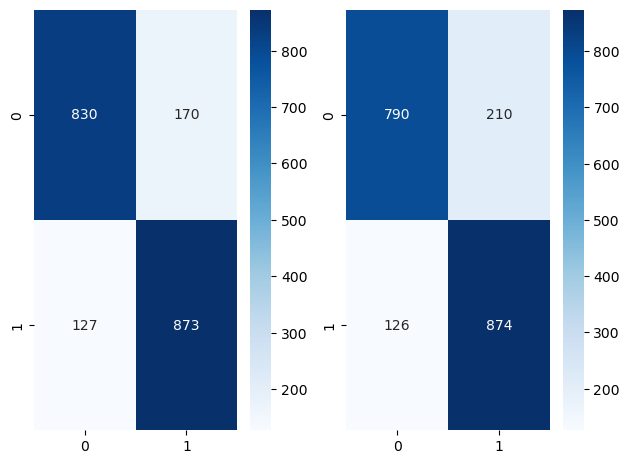

In [116]:
def made_predictions(predictions):
    array = []
    for pred in predictions:
        if max(pred) > 0.7:
            array.append([1])
        else:
            array.append([0])
    return np.array(array)

y_pred_best = best_model.predict(x_te_frog)
y_pred_best = made_predictions(y_pred_best)
best_cf = confusion_matrix(y_te_frog, y_pred_best)

y_pred_worse = worse_model.predict(x_te_frog)
y_pred_worse = made_predictions(y_pred_worse)
worse_cf = confusion_matrix(y_te_frog, y_pred_worse)

fig, ax = plt.subplots(1,2)
fig.tight_layout()
sns.heatmap(best_cf, annot=True, cmap='Blues', fmt='d', ax=ax[0])
sns.heatmap(worse_cf, annot=True, cmap='Blues', fmt='d', ax=ax[1])
fig.show()

#### Checking underfitting and overfitting

Since overfitting and underfitting is quite significant with these kinds of tasks we have to make sure it doesn't do that. As we see with our pictures, the best model is not specially overfitted or underfitted which is quite good. For our worse model we can see it jumps quite much between overfitting and not. This could mean our data is not getting augmented enough in the model for a high ``f1_score`` metric to better the model.

63/63 - 0s - 4ms/step - f1_score: 0.8556 - loss: 0.4879


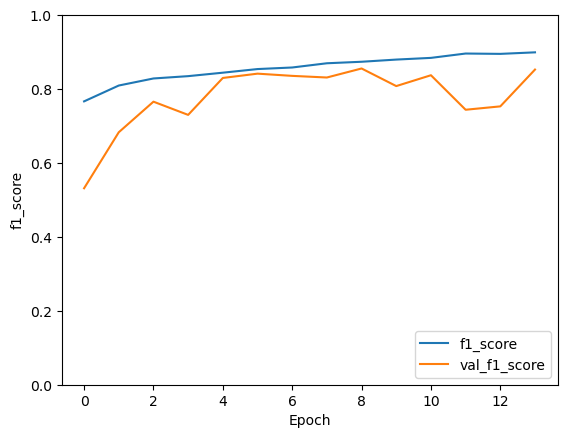

In [117]:
plt.plot(best_history.history['f1_score'], label='f1_score')
plt.plot(best_history.history['val_f1_score'], label = 'val_f1_score')
plt.xlabel('Epoch')
plt.ylabel('f1_score')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = best_model.evaluate(x_te_frog, y_te_frog, verbose=2)

63/63 - 0s - 4ms/step - f1_score: 0.7975 - loss: 0.5291


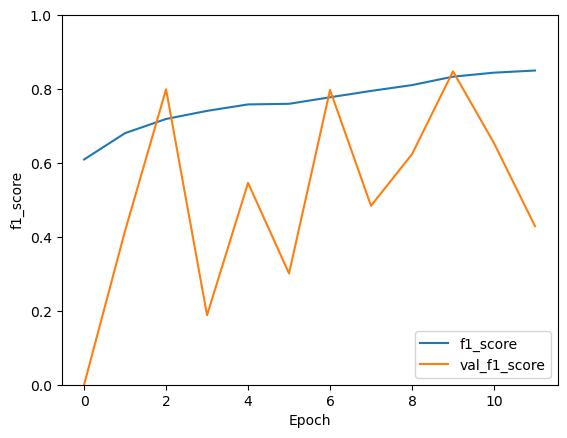

In [118]:
plt.plot(worse_history.history['f1_score'], label='f1_score')
plt.plot(worse_history.history['val_f1_score'], label = 'val_f1_score')
plt.xlabel('Epoch')
plt.ylabel('f1_score')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = worse_model.evaluate(x_te_frog, y_te_frog, verbose=2)

#### Task 2b)

Found this frog picture from Google: "https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.wcs.org%2Fget-involved%2Fupdates%2Ffascinating-frogs&psig=AOvVaw28_HGqOe7S2sxjPK3bsI5N&ust=1744278715616000&source=images&cd=vfe&opi=89978449&ved=0CBQQjRxqFwoTCKDFld_WyowDFQAAAAAdAAAAABAE"

Used Tensorflow's own `load_img` to convert to picture to the right size. Convert the image over to an array, create a batch and normalized the values like we did with our training and test data. Make the models predict with the image. We used a threshold of 0.7 which means if the model is over 70% sure that it is a frog we consider the picture a frog.

In [120]:
img = tf.keras.utils.load_img('./media/frog_6.jpg', target_size=(32, 32))

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch
img_array = np.array(img_array) / 255.0

prediction = best_model.predict(img_array)
print(prediction)
if max(prediction) > 0.7:
    print('frog')
else:
    print('not frog')

prediction = worse_model.predict(img_array)
print(prediction)
if max(prediction) > 0.7:
    print('frog')
else:
    print('not frog')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[0.9541946]]
frog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[[0.9047824]]
frog


### Conclusion of task 1.

...

### Conclusion of task 2.

...